In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Dimensionality reduction is also helpful for data visualization.

Here we will study:
- *PCA*
- *random projection*
- *Locally Linear Embedding (LLE)*

If you pick two random points in a 3D unit cube, the average
distance will be roughly 0.66. But what about two points picked randomly in
a 1,000,000-dimensional unit hypercube? The average distance, believe it or
not, will be about 408.25 (roughly 1,000,0006)! This is counterintuitive: how
can two points be so far apart when they both lie within the same unit
hypercube? Well, there’s just plenty of space in high dimensions. As a result,
**high-dimensional datasets are at risk of being very sparse**: most training
instances are likely to be far away from each other

Theorotical solution to this is that we increase training data so as to reach a sufficient density, however that is not possible in real life.

### Approaches:
- **Projection** : When training instances are not that wide spread and lie closer to a lower subspace , we can project them onto that lower subspace perpendicularly(mostly)

- **Manifold Learning** : Example is swiss roll dataset.
 Many dimensionality reduction algorithms work by modeling the manifold
on which the training instances lie; this is called manifold learning. It relies
on the manifold assumption, also called the manifold hypothesis, which holds
that most real-world high-dimensional datasets lie close to a much lowerdimensional manifold. This assumption is very often empirically observed.

## PCA

demonstratio of preserving maximum variance by selecting hyperplanes(**Principal Components**)

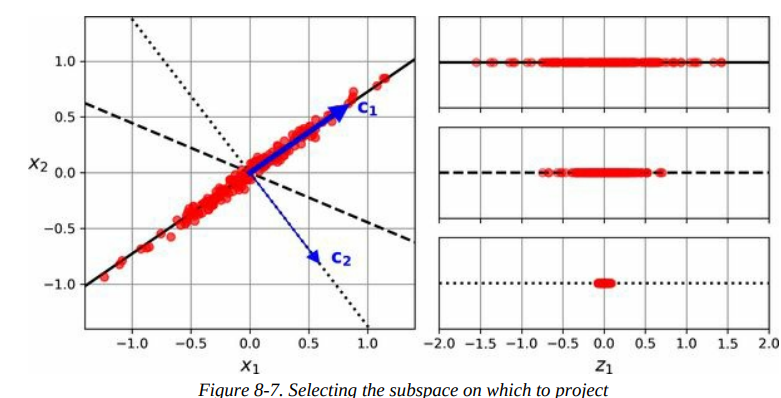

Let's obtain principal components of a 3D training set


In [3]:
depth =3
rows = 4
cols = 5
np_array_3d = np.random.rand(depth,rows, cols)

index = pd.MultiIndex.from_product([range(depth), range(rows)], names=['depth', 'rows'])

df_2d = pd.DataFrame(np_array_3d.reshape(depth*rows, cols), index=index, columns=range(cols))

In [4]:
X= df_2d

X_centered = X - X.mean(axis =0)
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
U.shape, s.shape, Vt.shape


((12, 5), (5,), (5, 5))

In [8]:
Vt

array([[-0.70905393, -0.453872  ,  0.07316861, -0.52944979, -0.07464582],
       [-0.38970332,  0.1910693 , -0.30435825,  0.19986595,  0.82404096],
       [-0.57494219,  0.54203141,  0.2308721 ,  0.39475746, -0.40805398],
       [-0.04403974,  0.20971369, -0.89048266, -0.19434381, -0.35121472],
       [-0.11347167, -0.64785403, -0.23611673,  0.69723278, -0.15976443]])

In [10]:
W2 = Vt[:2].T
X2D = X_centered @ W2

X2D

0         1
depth rows                    
0     0     0.042993 -0.138396
      1    -0.260182  0.176265
      2     0.650017 -0.063624
      3     0.079915 -0.327116
1     0     0.639670  0.345701
      1     0.523069 -0.361077
      2    -0.054796  0.427543
      3    -0.631106  0.356195
2     0    -0.225415 -0.267373
      1    -0.433042 -0.431720
      2     0.199667  0.326615
      3    -0.530791 -0.043012

### Usinf sklearn

In [11]:
from sklearn.decomposition import PCA

In [12]:
pca = PCA(n_components= 2)

X2D = pca.fit_transform(X)
X2D

array([[ 0.04299324,  0.13839568],
       [-0.26018177, -0.17626501],
       [ 0.65001674,  0.06362436],
       [ 0.07991457,  0.32711618],
       [ 0.63967015, -0.3457008 ],
       [ 0.52306916,  0.36107741],
       [-0.05479586, -0.42754314],
       [-0.63110624, -0.35619462],
       [-0.22541494,  0.26737281],
       [-0.43304177,  0.4317204 ],
       [ 0.19966731, -0.32661519],
       [-0.5307906 ,  0.04301192]])

In [14]:
pca.explained_variance_, pca.explained_variance_ratio_

(array([0.19477007, 0.09883888]), array([0.48289182, 0.24505042]))

**Lets try this on MNIST**

In [15]:
from sklearn.datasets import fetch_openml

In [17]:
mnist = fetch_openml('mnist_784', as_frame = False)

c:\Users\aarad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [18]:
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 784), (10000, 784), (60000,), (10000,))

mnist dataset has 784 features (28x28 pixels) and 70,000 instances.
So pca will generate 784 principal components.
Each principal component is a linear combination of the original features.
each component is orthogonal to the others.
each component has its own variance.


In [29]:
pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)

# 784 features sp shape of cumsum is (784,)                     
cumsum.shape

(784,)

In [31]:
# Lets find dimension d for which variance share is above 95%
d = np.argmax(cumsum >= 0.95) + 1

# why +1?
# because we want to include the dth dimension
d

154

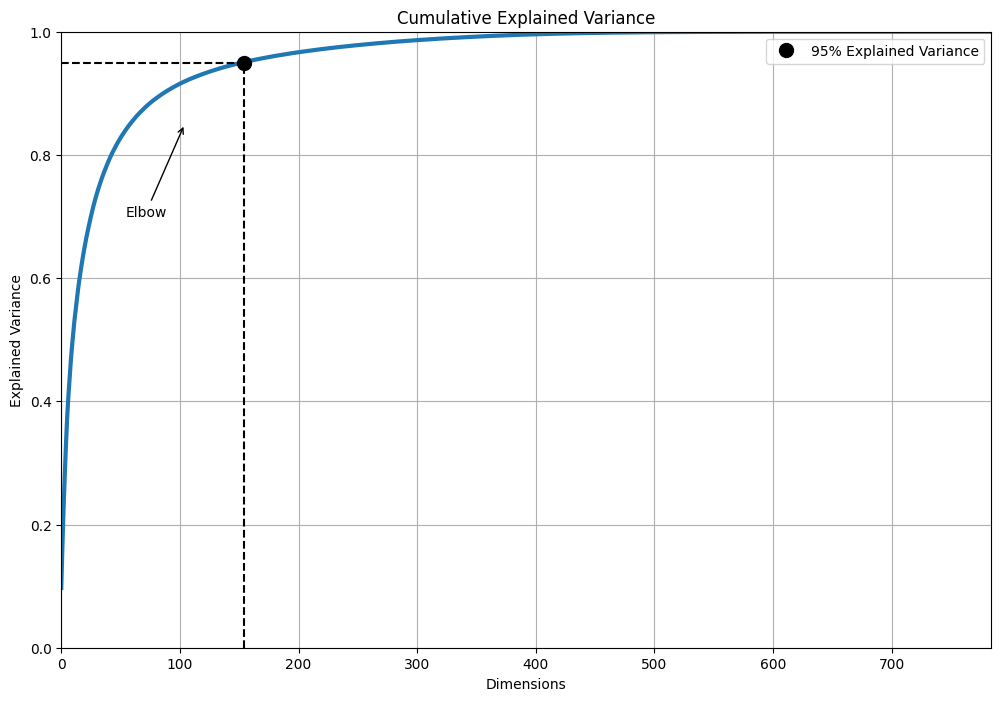

In [93]:
# plotting the cumsum
plt.figure(figsize=(12,8))
plt.plot(cumsum, linewidth = 3)
plt.axis([0, 784, 0, 1])
plt.xlabel('Dimensions')
plt.ylabel('Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.95,xmax=d/784, color='k', linestyle='--')
plt.axvline(x=d, ymax=0.95, color='k', linestyle='--')
# plt.plot([d,d],[0,0.95], marker='o', markersize=10, color='g')
plt.plot(d,0.95,"ko", markersize='10', label="95% Explained Variance")
plt.annotate("Elbow", xy=(d-50, 0.85), xytext=(d-100, 0.7),
             arrowprops=dict(arrowstyle='->')),
plt.legend()
plt.plot
plt.grid(True)   
plt.show()

Now we can set `n_componenets` parameter of pca instance to `d`.

However instead of always calculating `d` first and then again creating an instance, we can se `n_components` to a float between 0.0 to 1.0, which is variance ratio

In [34]:
pca = PCA(n_components= 0.95)
X_reduced = pca.fit_transform(X_train)

X_reduced.shape, pca.n_components_

((60000, 154), 154)

**Lets try PCA with some models**

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

In [100]:
clf = make_pipeline(
    PCA(random_state=42),
    RandomForestClassifier(random_state=42)
)

param_dsitrib ={
    "pca__n_components": np.arange(10,80),
    "randomforestclassifier__n_estimators": np.arange(50,500),
}

rnd_search = RandomizedSearchCV(
    clf,
    param_dsitrib,
    n_iter = 5,
    cv=3
)

rnd_search.fit(X_train[:1000],y_train[:1000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=5,
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 5...
       401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413,
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       492, 493, 494, 495, 496, 497, 498, 499])})

In [101]:
rnd_search.best_params_


{'randomforestclassifier__n_estimators': 324, 'pca__n_components': 25}

In [103]:
X_recovered = pca.inverse_transform(X_reduced)

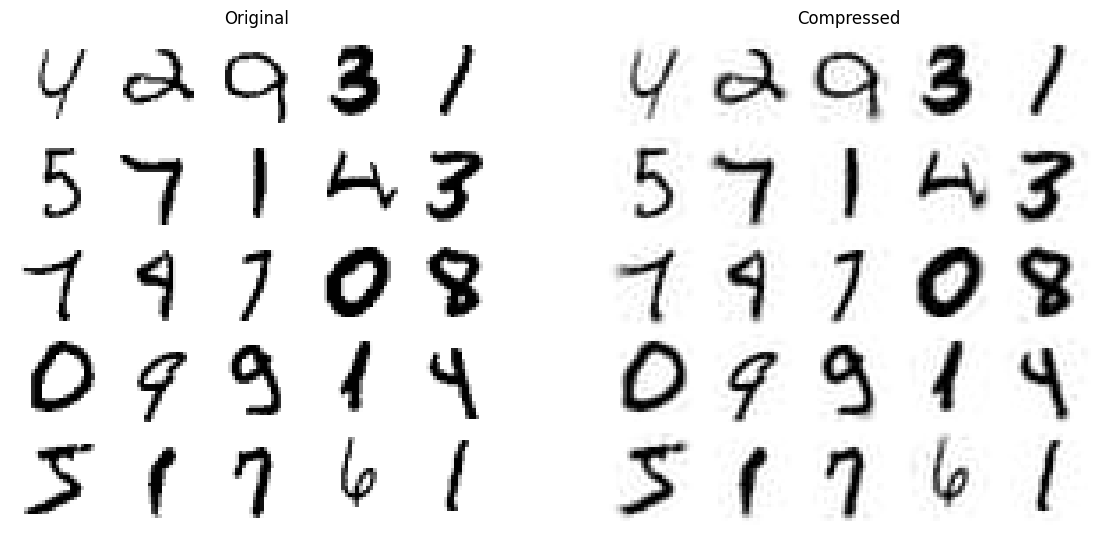

In [113]:
plt.figure(figsize=(14,8))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")
            

### **Randomized PCA**
If you set the svd_solver hyperparameter to "randomized", Scikit-Learn uses
a stochastic algorithm called randomized PCA that quickly finds an
approximation of the first d principal components. Its computational
complexity is O(m × d ) + O(d ), instead of O(m × n ) + O(n ) for the full
SVD approach, so it is dramatically faster than full SVD when d is much
smaller than n:

In [114]:
rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)


### **Incremental PCA**

Incremental PCA (IPCA) algorithms have been developed that
allow you to split the training set into mini-batches and feed these in one
mini-batch at a time. This is useful for large training sets and for applying
PCA online 

In [115]:
from sklearn.decomposition import IncrementalPCA

In [116]:
n_batches = 100
inc_pca = IncrementalPCA( n_components= 154 )
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)


X_reduced = inc_pca.transform(X_train)
X_reduced.shape

(60000, 154)